1. Install and Import Dependencies

In [151]:
%pip install gymnasium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [152]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132

Looking in indexes: https://download.pytorch.org/whl/cu132
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [153]:
%pip install stable-baselines3[extra] protobuf==3.20.*

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [154]:
%pip install mss pydirectinput pytesseract

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [155]:
# MSS used for screen cap
from mss import mss

# Sending commands
import pydirectinput
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# OpenCV allows us to do frame processing
import cv2

# Transformational framework
import numpy as np

# OCR for game over extraction
import pytesseract

# Visualize captured frames
from matplotlib import pyplot as plt

# Bring in time for pauses
import time

# Environment components
from gymnasium import Env
from gymnasium.spaces import Box, Discrete

2. Build the Environment

2.1 Create Environment

In [156]:
class WebGame(Env):
    # setup the environment action and observation shapes
    def __init__(self):
        # subclass model
        super().__init__()

        # setup spaces
        self.observation_space = Box(low=0, high=255, shape=(1,120,160), dtype=np.uint8)
        self.action_space = Discrete(3)

        # define extraction parameters for the game
        self.cap = mss()
        self.game_location = {'top': 300, 'left': 0, 'width': 600, 'height': 900}
        self.done_location = {'top': 640, 'left': 850, 'width': 870, 'height': 100}

    # called to do something in the game
    def step(self, action):
        # action key - 0 = space(jump), 1 = duck, 2 = no action
        action_map = {
            0: 'space',
            1: 'down',
            2: 'no_op'
        }
        if action != 2:
            pydirectinput.press(action_map[action])
        #check if game is done
        done, done_cap = self.get_done()
        #get the next observation
        new_obervation = self.get_observation()
        #reward - 1 point for every frame alive
        reward = 1   
        #info directory
        info = {}

        terminated = done
        truncated = False
        return new_obervation, reward, terminated, truncated, info

    # visualize the game
    def render(self):
        cv2.imshow('Game', np.array(self.cap.grab(self.game_location))[:,:,:3])
        if cv2.waitKey(1) & 0xFF == ord('q'):
            self.close()
            

    # this closes down on the observation
    def close(self):
        cv2.destroyAllWindows()

    # restart the game
    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        time.sleep(1)

        pydirectinput.click(x=150, y=150)

        pydirectinput.press('space')

        observation = self.get_observation()

        return observation, {}

    # get the part of the observation of the game that we want
    def get_observation(self):
        # get screen capture of the game
        raw = np.array(self.cap.grab(self.game_location))[:,:,:3].astype(np.uint8)

        # grayscale
        gray = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)

        # resize
        resized = cv2.resize(gray, (160,120))

        # add channels first
        channel = np.reshape(resized, (1,120,160))

        return channel

    # Get the done text using OCR
    def get_done(self):
        # Get done screen
        done_cap = np.array(self.cap.grab(self.done_location))[:,:,:3]

        # Valid done text
        done_strings = ['GAMEOVER', 'GAHEOVER', 'G&GAMEOVER', 'GSAMEOVER']

        # Apply OCR
        done = False
        res = pytesseract.image_to_string(done_cap, config='--psm 7').upper()

        res = res.replace(' ', '').replace('\n', '')

        if res in done_strings:
            done = True

        return done, done_cap

2.2 Test Environment

In [157]:
env = WebGame()

C:\Users\sanid\AppData\Local\Temp\ipykernel_46532\3018362789.py:12: DeprecationWarning: mss.mss is deprecated and will be removed in a future release; use mss.MSS instead
  self.cap = mss()


In [158]:
result = env.reset()

print(type(result))
print(len(result))

<class 'tuple'>
2


In [159]:
env.reset()

(array([[[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]]],
       shape=(1, 120, 160), dtype=uint8),
 {})

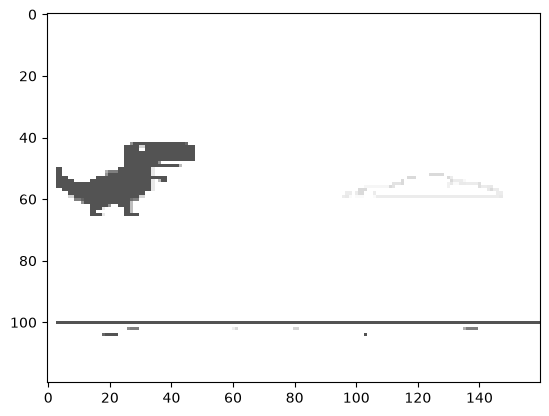

In [160]:
plt.imshow(cv2.cvtColor(env.get_observation()[0], cv2.COLOR_GRAY2BGR))

In [161]:
done, done_cap = env.get_done()

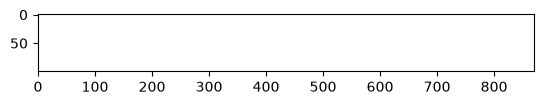

In [162]:
plt.imshow(done_cap)

In [163]:
done

False

In [164]:
env.get_done()

(True,
 array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 2

In [165]:
print(repr(pytesseract.image_to_string(done_cap)))

''


3. Train the Model

3.1 Create Callback

In [167]:
# Import os for file path management
import os 
# Import Base Callback for saving models
from stable_baselines3.common.callbacks import BaseCallback
# Check Environment    
from stable_baselines3.common import env_checker

In [168]:
env_checker.check_env(env)

In [169]:
class TrainAndLoggingCallback(BaseCallback):

    def __init__(self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, 'best_model_{}'.format(self.n_calls))
            self.model.save(model_path)

        return True

In [170]:
CHECKPOINT_DIR = './train/'
LOG_DIR = './logs/'

In [171]:
callback = TrainAndLoggingCallback(check_freq=1000, save_path=CHECKPOINT_DIR)

3.2 Build DQN and Train

In [172]:
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

In [173]:
env = WebGame()

C:\Users\sanid\AppData\Local\Temp\ipykernel_46532\3018362789.py:12: DeprecationWarning: mss.mss is deprecated and will be removed in a future release; use mss.MSS instead
  self.cap = mss()


In [174]:
model = DQN('CnnPolicy', env, tensorboard_log=LOG_DIR, verbose=1, buffer_size=10000, learning_starts=1000)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [176]:
model.learn(total_timesteps=200, callback=callback)

Logging to ./logs/DQN_5
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 17.2     |
|    ep_rew_mean      | 17.2     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2        |
|    time_elapsed     | 34       |
|    total_timesteps  | 69       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16.5     |
|    ep_rew_mean      | 16.5     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2        |
|    time_elapsed     | 61       |
|    total_timesteps  | 132      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16.4     |
|    ep_rew_mean      | 16.4     |
|    exploration_rate | 0.05     |
| time/               |        

4. Test out Model

In [177]:
for episode in range(5):

    obs, info = env.reset()

    terminated = False
    truncated = False
    total_reward = 0

    while not (terminated or truncated):

        action, _ = model.predict(obs)

        obs, reward, terminated, truncated, info = env.step(int(action))

        time.sleep(0.01)

        total_reward += reward

    print('Total Reward for episode {} is {}'.format(episode, total_reward))

    time.sleep(2)

Total Reward for episode 0 is 27
Total Reward for episode 1 is 30
Total Reward for episode 2 is 78
Total Reward for episode 3 is 30
Total Reward for episode 4 is 28
